# Severity Prediction Modeling

Objective:
-ปัจจัยก่อนเกิดอุบัติเหตุอะไรที่สัมพันธ์กับความรุนแรงและมันส่งผลต่อแต่ละระดับ severity อย่างไร
- Train a model to predict accident severity (multiclass)
- Use only pre-incident features (no leakage)
- Emphasize interpretability alongside performance

Modeling approach:
- Tree-based models (CatBoost / LightGBM)
- Evaluation with stratified split
- Feature importance and SHAP for interpretation


STEP 0 — Install

In [1]:
!pip install scikit-learn shap



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Loading data...
Data Shape: (6985228, 19)
Features available: ['Severity', 'Log_Distance', 'Log_Duration', 'Hour_sin', 'Hour_cos', 'Month_sin', 'Month_cos', 'Is_Critical_Description', 'Temperature(F)', 'Humidity(%)', 'Visibility(mi)', 'Wind_Speed(mph)', 'Precipitation(in)', 'Amenity', 'Crossing', 'Junction', 'Traffic_Signal', 'Area_Density_Level_Medium', 'Area_Density_Level_High']
✅ พบ Feature: Is_Critical_Description
Sampling data to 1,000,000 rows (Stratified)...
Sampled Shape: (1000000, 19)
✅ Column 'Severity' is present. Ready to split.
Train set: (800000, 18)
Test set:  (200000, 18)

Training Random Forest Model...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=-1)]: Done  10 tasks      | elapsed:    3.0s
[Parallel(n_jobs=-1)]: Done 160 tasks      | elapsed:   25.5s
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:   30.8s finished
[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done  10 tasks      | elapsed:    0.0s


Training Completed!

Predicting...


[Parallel(n_jobs=20)]: Done 160 tasks      | elapsed:    0.8s
[Parallel(n_jobs=20)]: Done 200 out of 200 | elapsed:    0.9s finished



=== Classification Report (Balanced Model) ===
              precision    recall  f1-score   support

           1       0.12      0.64      0.20      1929
           2       0.94      0.75      0.83    155582
           3       0.53      0.75      0.62     37200
           4       0.31      0.80      0.45      5289

    accuracy                           0.75    200000
   macro avg       0.48      0.73      0.53    200000
weighted avg       0.84      0.75      0.78    200000



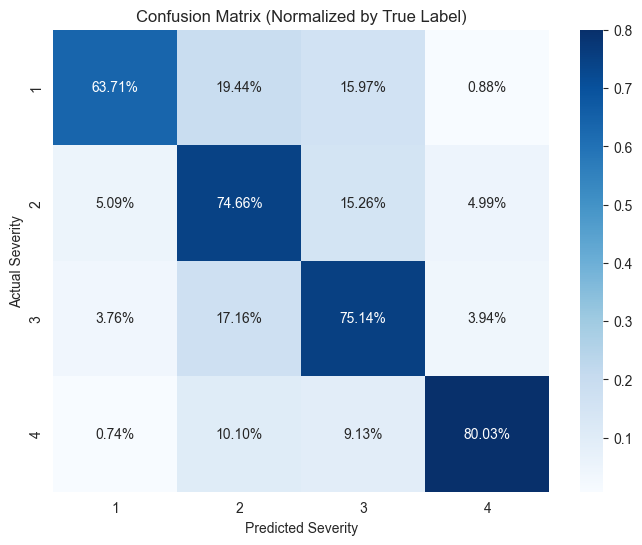

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_24516\2300732702.py:128: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance.head(20), x="importance", y="feature", palette="viridis")


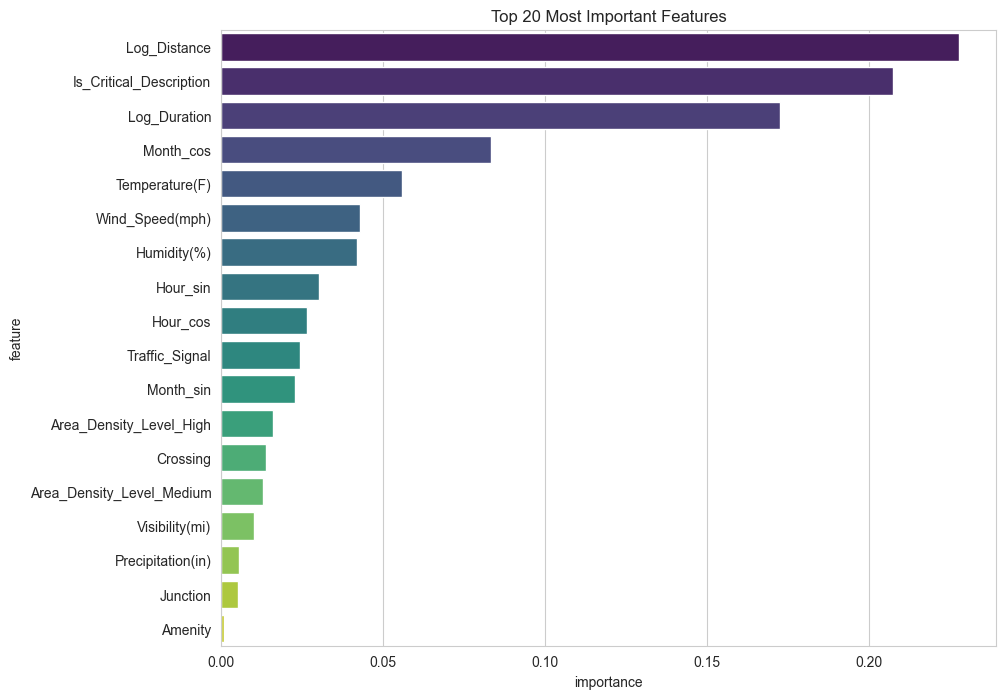


Top 10 Features:
                    feature  importance
0              Log_Distance    0.227798
6   Is_Critical_Description    0.207386
1              Log_Duration    0.172465
5                 Month_cos    0.083458
7            Temperature(F)    0.055721
10          Wind_Speed(mph)    0.042824
8               Humidity(%)    0.041875
2                  Hour_sin    0.030276
3                  Hour_cos    0.026591
15           Traffic_Signal    0.024388

Saved feature importance to CSV.


In [2]:
# ==========================================
# 1. Import Libraries
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# ตั้งค่าการแสดงผล
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

# ==========================================
# 2. Load Data (ข้อมูลที่พร้อมใช้จากไฟล์ 03)
# ==========================================
print("Loading data...")
# โหลดไฟล์ที่เราเตรียมไว้ล่าสุด (ที่มี Features ใหม่ครบถ้วน)
df = pd.read_parquet("../data/processed/accidents_for_model.parquet")

print(f"Data Shape: {df.shape}")
print("Features available:", df.columns.tolist())

# ตรวจสอบว่ามี Feature ใหม่หรือไม่
if 'Is_Critical_Description' in df.columns:
    print("✅ พบ Feature: Is_Critical_Description")
else:
    print("⚠️ ไม่พบ Is_Critical_Description (ผลลัพธ์อาจไม่ดีเท่าที่ควร)")

# ==========================================
# 3. Sampling (Stratified using train_test_split)
# ==========================================
# แก้ปัญหา KeyError โดยใช้ train_test_split เพื่อสุ่มข้อมูลแทน groupby
from sklearn.model_selection import train_test_split

TARGET = "Severity"
SAMPLE_SIZE = 1000000  # จำนวนแถวที่ต้องการ

if len(df) > SAMPLE_SIZE:
    print(f"Sampling data to {SAMPLE_SIZE:,} rows (Stratified)...")
    
    # ใช้ train_test_split เพื่อดึงข้อมูลออกมาตามจำนวนที่ต้องการ โดยคงสัดส่วน Severity ไว้
    df_sample, _ = train_test_split(
        df, 
        train_size=SAMPLE_SIZE, 
        stratify=df[TARGET], 
        random_state=42
    )
else:
    df_sample = df.copy()

print(f"Sampled Shape: {df_sample.shape}")

# เช็กด่วนว่า Severity ยังอยู่ไหม (ควรจะต้องอยู่)
if TARGET in df_sample.columns:
    print(f"✅ Column '{TARGET}' is present. Ready to split.")
else:
    print(f"❌ Error: '{TARGET}' column is missing! Check sampling logic.")

# ==========================================
# 4. Split Features / Target
# ==========================================
X = df_sample.drop(columns=[TARGET])
y = df_sample[TARGET]

# แบ่ง Train/Test (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Train set: {X_train.shape}")
print(f"Test set:  {X_test.shape}")
# ==========================================
# 5. Train Model (Random Forest with 'Balanced' Weight)
# ==========================================
print("\nTraining Random Forest Model...")

# จุดเปลี่ยนสำคัญ: class_weight='balanced'
# มันจะปรับน้ำหนักให้อัตโนมัติ: Severity 4 (หายาก) จะมีคะแนนสูงกว่า Severity 2 (หาง่าย)
rf = RandomForestClassifier(
    n_estimators=200,          # จำนวนต้นไม้ (ลดลงจาก 400 เพื่อความเร็ว แต่ยังแม่นยำ)
    max_depth=20,              # ความลึก (เพิ่มขึ้นนิดหน่อยเพื่อให้เรียนรู้ Pattern ยากๆ ได้)
    min_samples_leaf=4,        # ป้องกัน Overfitting
    class_weight='balanced',   # <--- HERO FEATURE: แก้ Recall ต่ำ
    random_state=42,
    n_jobs=-1,                 # ใช้ทุก Core ของ CPU
    verbose=1
)

rf.fit(X_train, y_train)
print("Training Completed!")

# ==========================================
# 6. Model Evaluation
# ==========================================
print("\nPredicting...")
y_pred = rf.predict(X_test)

print("\n=== Classification Report (Balanced Model) ===")
print(classification_report(y_test, y_pred))

# ==========================================
# 7. Visualization: Normalized Confusion Matrix
# ==========================================
# ดูเป็น % จะเข้าใจง่ายกว่าดูเป็นจำนวนคน
cm = confusion_matrix(y_test, y_pred, normalize='true') 

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='.2%', cmap='Blues', 
            xticklabels=[1, 2, 3, 4], yticklabels=[1, 2, 3, 4])
plt.xlabel('Predicted Severity')
plt.ylabel('Actual Severity')
plt.title('Confusion Matrix (Normalized by True Label)')
plt.show()

# ==========================================
# 8. Feature Importance (Check the New Features!)
# ==========================================
# มาดูกันว่า Is_Critical_Description ติดอันดับไหม?
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=feature_importance.head(20), x="importance", y="feature", palette="viridis")
plt.title("Top 20 Most Important Features")
plt.show()

print("\nTop 10 Features:")
print(feature_importance.head(10))

# ==========================================
# 9. Save Feature Importance for Report
# ==========================================
feature_importance.to_csv("../data/processed/final_feature_importance.csv", index=False)
print("\nSaved feature importance to CSV.")